# Segmentation

## Init

In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np

In [2]:
# from ModSegment import main2d, main3d
from ModSegment import (
    probabilistically_combine,
    colors,
    calc_jerk_in_time,
    signed_norm,
    moving_average,
    calc_acceleration,
    detect_brutal_changes,
)
from utils import read_robot_data
import downsampling as ds

pygame 2.6.1 (SDL 2.32.50, Python 3.11.2)
Hello from the pygame community. https://www.pygame.org/contribute.html


<frozen importlib._bootstrap>:241: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.


In [3]:
from itertools import cycle
import shutil
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from collections import OrderedDict
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, accuracy_score
import datetime as dt

# from scipy import signal
from scipy.interpolate import make_splrep

# from scipy.interpolate import UnivariateSpline
import os
from pathlib import Path
from tqdm.auto import tqdm
from pprint import pprint
import ruptures as rpt
from ruptures.metrics import precision_recall, hausdorff, randindex
import distancia

In [4]:
from segmentation_utils import (
    # extract_eef_data_from_rosbag,
    get_ground_truth_segmentation,
    # get_bagfiles_from_json,
    read_h5_data,
    get_gtdict_filenames,
    ts2df,
)

In [5]:
# %matplotlib ipympl
%load_ext autoreload
%autoreload 2

In [6]:
# TRANSP_BACK_PLOT = True
TRANSP_BACK_PLOT = False

## Hyperparameters

In [85]:
window_size = 400  # file 0
# window_size = 600  # file 2
# window_size = 350  # file 4

## Data

In [8]:
# data_path_root = Path("../table-task-ur5e")
data_path_root = Path("/home/kir0ul/Projects/sdl") / "data"
assert data_path_root.exists()

In [9]:
ground_truth_segm_file = data_path_root.parent / "segm_ground_truth.json"
assert ground_truth_segm_file.exists()

In [10]:
filenums = [0, 1]
# filenums = [2, 3]
# filenums = [4, 5]

In [11]:
filenum = filenums[0]

In [12]:
gt_segm_dict, video_file, hdf5_file = get_gtdict_filenames(
    ground_truth_segm_file=ground_truth_segm_file, filenum=filenum
)
pprint(gt_segm_dict)

{'hdf5': 'long-task-1.h5',
 'segments': {'close-drawer': {'end': 1769723276, 'ini': 1769723270},
              'grasping': [{'end': 1769723226, 'ini': 1769723222},
                           {'end': 1769723239, 'ini': 1769723237},
                           {'end': 1769723253, 'ini': 1769723251},
                           {'end': 1769723270, 'ini': 1769723267},
                           {'end': 1769723296, 'ini': 1769723288}],
              'open-drawer': {'end': 1769723231, 'ini': 1769723226},
              'placing': [{'end': 1769723245, 'ini': 1769723239},
                          {'end': 1769723258, 'ini': 1769723253}],
              'pouring': {'end': 1769723309, 'ini': 1769723296},
              'reaching': [{'end': 1769723222, 'ini': 1769723215},
                           {'end': 1769723237, 'ini': 1769723234},
                           {'end': 1769723251, 'ini': 1769723248},
                           {'end': 1769723267, 'ini': 1769723262},
                           {'end

In [13]:
hdf5_path = data_path_root / hdf5_file
video_path = data_path_root / video_file

## Preprocessing

In [14]:
joint_data, tf_data, wrench_data, gripper_data = read_h5_data(fname=hdf5_path)

['gripper_info', 'joint_state_info', 'transform_info', 'wrench_info']


In [15]:
traj = ts2df(tf_data=tf_data, gripper_data=gripper_data)
traj

,x,y,z,timestamp,gripper
0,0.133347,-0.491981,0.488070,2026-01-29 16:46:49.273737185-05:00,0.01
1,0.133354,-0.491975,0.488080,2026-01-29 16:46:49.275736664-05:00,0.01
2,0.133358,-0.491972,0.488044,2026-01-29 16:46:49.277680340-05:00,0.01
3,0.133351,-0.491997,0.488007,2026-01-29 16:46:49.279664024-05:00,0.01
4,0.133328,-0.491981,0.488071,2026-01-29 16:46:49.281634923-05:00,0.01
...,...,...,...,...,...
53132,-0.061511,-0.594210,0.273193,2026-01-29 16:48:36.122627710-05:00,0.01
53133,-0.061486,-0.594203,0.273203,2026-01-29 16:48:36.124703544-05:00,0.01
53134,-0.061480,-0.594227,0.273175,2026-01-29 16:48:36.126640743-05:00,0.01
53135,-0.061488,-0.594235,0.273185,2026-01-29 16:48:36.128663112-05:00,0.01


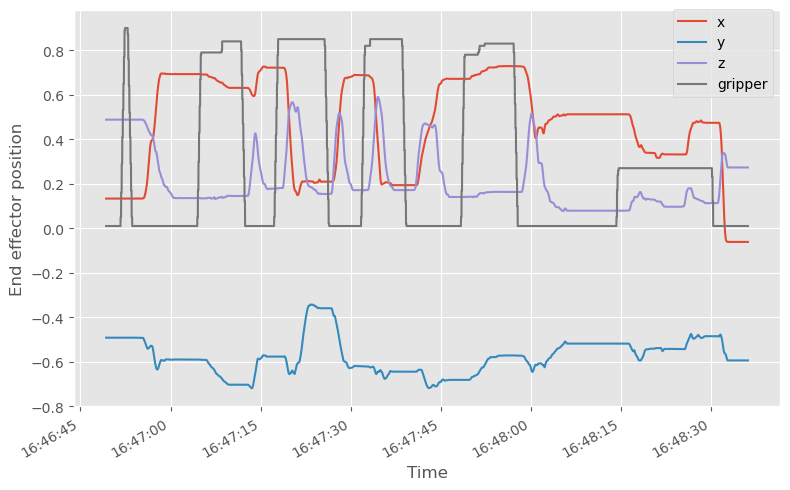

In [16]:
with plt.style.context("ggplot"):
    # with plt.style.context("ggplot"):
    fig, ax = plt.subplots(figsize=(8, 5))
    # cmap = mpl.colormaps.get("tab10").colors
    ax.plot(traj.timestamp, traj.x, label="x")  # , color=cmap[0])
    ax.plot(traj.timestamp, traj.y, label="y")  # , color=cmap[1])
    ax.plot(traj.timestamp, traj.z, label="z")  # , color=cmap[2])
    ax.plot(traj.timestamp, traj.gripper, label="gripper")  # , color=cmap[3])
    ax.set_xlabel("Time")
    ax.set_ylabel("End effector position")
    # ax.legend(loc="best")
    ax.legend(bbox_to_anchor=(1.0, 1.02))
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

## Ground truth (with objects moving activation functions)

In [17]:
nsegments = 0
obj_labels = []
for segm_key, segm_val in gt_segm_dict["segments"].items():
    if isinstance(segm_val, list):
        nsegments += len(segm_val)
        for jdx, _ in enumerate(segm_val):
            obj_labels.append(f"obj_{segm_key}_{jdx + 1}")
    elif isinstance(segm_val, dict):
        nsegments += 1
        obj_labels.append(f"obj_{segm_key}")
    else:
        raise ValueError("Unexpected value in ground truth JSON file")
nsegments, obj_labels

(20,
 ['obj_reaching_1',
  'obj_reaching_2',
  'obj_reaching_3',
  'obj_reaching_4',
  'obj_reaching_5',
  'obj_open-drawer',
  'obj_grasping_1',
  'obj_grasping_2',
  'obj_grasping_3',
  'obj_grasping_4',
  'obj_grasping_5',
  'obj_placing_1',
  'obj_placing_2',
  'obj_releasing_1',
  'obj_releasing_2',
  'obj_releasing_3',
  'obj_releasing_4',
  'obj_releasing_5',
  'obj_close-drawer',
  'obj_pouring'])

In [18]:
objects = np.zeros((traj.shape[0], nsegments))
objects.shape

(53137, 20)

In [19]:
col_i = 0
for sect_i, sect_key in enumerate(gt_segm_dict["segments"].keys()):
    sect_dict_current = gt_segm_dict["segments"][sect_key]
    if isinstance(sect_dict_current, list):
        for sect_j, sect_cur in enumerate(sect_dict_current):
            xs = traj.timestamp[
                (
                    traj.timestamp
                    > pd.Timestamp(
                        dt.datetime.fromtimestamp(sect_cur["ini"]),
                        # - dt.timedelta(hours=1),
                        tz="EST",
                    )
                )
                & (
                    traj.timestamp
                    < pd.Timestamp(
                        dt.datetime.fromtimestamp(sect_cur["end"]),
                        # - dt.timedelta(hours=1),
                        tz="EST",
                    )
                )
            ]
            print(col_i)
            objects[xs.index, col_i] = np.ones_like(xs)
            col_i += 1

    elif isinstance(sect_dict_current, dict):
        xs = traj.timestamp[
            (
                traj.timestamp
                > pd.Timestamp(
                    dt.datetime.fromtimestamp(sect_dict_current["ini"]),
                    # - dt.timedelta(hours=1),
                    tz="EST",
                )
            )
            & (
                traj.timestamp
                < pd.Timestamp(
                    dt.datetime.fromtimestamp(sect_dict_current["end"]),
                    # - dt.timedelta(hours=1),
                    tz="EST",
                )
            )
        ]
        print(col_i)
        objects[xs.index, col_i] = np.ones_like(xs)
        col_i += 1
    else:
        raise ValueError("Unexpected value in ground truth JSON file")

objects

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

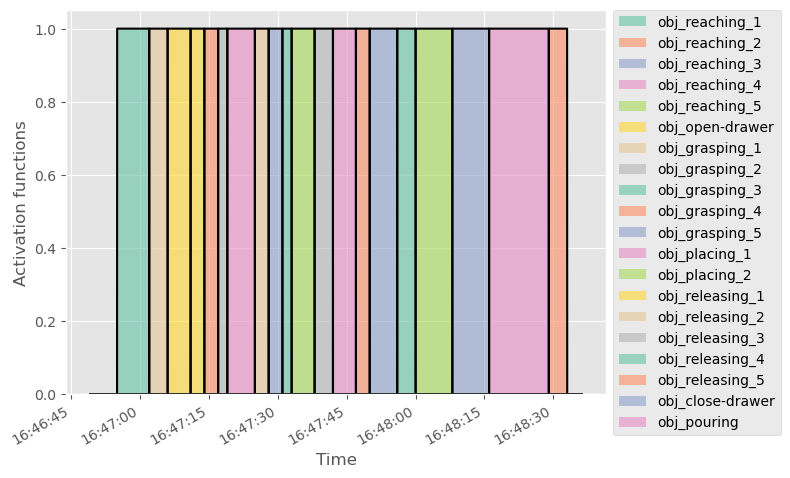

In [20]:
with plt.style.context("ggplot"):
    cmap = mpl.colormaps.get("Set2").colors
    fig, ax = plt.subplots(figsize=(8, 5))
    for idx in range(objects.shape[1]):
        ax.plot(
            traj.timestamp,
            objects[:, idx],
            # label=obj_labels[idx],
            color="k",
            # linewidth=1.5,
        )
    ax.stackplot(
        traj.timestamp,
        objects.T,
        labels=obj_labels,
        alpha=0.6,
        colors=cmap,
    )
    ax.set_xlabel("Time")
    ax.set_ylabel("Activation functions")
    # ax.legend(loc="best")
    ax.legend(bbox_to_anchor=(1.0, 1.02))
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

In [21]:
for idx in range(objects.shape[1]):
    traj[obj_labels[idx]] = objects[:, idx]
traj

,x,y,z,timestamp,gripper,obj_reaching_1,obj_reaching_2,obj_reaching_3,obj_reaching_4,obj_reaching_5,...,obj_grasping_5,obj_placing_1,obj_placing_2,obj_releasing_1,obj_releasing_2,obj_releasing_3,obj_releasing_4,obj_releasing_5,obj_close-drawer,obj_pouring
0,0.133347,-0.491981,0.488070,2026-01-29 16:46:49.273737185-05:00,0.01,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.133354,-0.491975,0.488080,2026-01-29 16:46:49.275736664-05:00,0.01,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.133358,-0.491972,0.488044,2026-01-29 16:46:49.277680340-05:00,0.01,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.133351,-0.491997,0.488007,2026-01-29 16:46:49.279664024-05:00,0.01,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.133328,-0.491981,0.488071,2026-01-29 16:46:49.281634923-05:00,0.01,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53132,-0.061511,-0.594210,0.273193,2026-01-29 16:48:36.122627710-05:00,0.01,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53133,-0.061486,-0.594203,0.273203,2026-01-29 16:48:36.124703544-05:00,0.01,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53134,-0.061480,-0.594227,0.273175,2026-01-29 16:48:36.126640743-05:00,0.01,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53135,-0.061488,-0.594235,0.273185,2026-01-29 16:48:36.128663112-05:00,0.01,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Segment data

In [22]:
def segment(
    time,
    data,
    base_thresh=1000,
    segment_size=10,
    window_size=64,
    grace_thresh=32,
    plot=False,
    mode="variations",
):
    """
    Detects changepoints in the given data based on the jerk values.
    Parameters:
    - time (array-like): The time values corresponding to the data.
    - data (array-like): The data to be segmented.
    - base_thresh (int, optional): The threshold value for segment detection. Defaults to 1000.
    - segment_size (int, optional): The size of each segment. Defaults to 256.
    - window_size (int, optional): The size of the moving average window. Defaults to 64.
    - grace_thresh (int, optional): The grace threshold for segment detection. Defaults to 32.
    - plot (bool, optional): Whether to plot the detected changepoints. Defaults to False.
    Returns:
    - segments (list): A list of indices indicating the detected changepoints in the data.
    """

    # Verificar que time y data tengan la misma longitud
    if len(time) != len(data):
        raise ValueError(
            "El tamaño del array de tiempo no coincide con el tamaño del array de datos."
        )

    # Comprobar si existen valores NaN
    if np.isnan(time).any() or np.isnan(data).any():
        raise ValueError("Existen valores NaN en los datos o en el tiempo.")

    # Verificar que los parámetros son válidos
    if base_thresh < 0 or segment_size <= 0 or window_size <= 0 or grace_thresh < 0:
        raise ValueError("Los valores de los parámetros no son válidos.")

    jerk = calc_jerk_in_time(time, data)
    total_jerk = signed_norm(jerk)
    avg_jerk = moving_average(total_jerk, window_size)
    norm_avg_jerk = avg_jerk / np.max(avg_jerk)

    # *Acceleration
    acceleration = calc_acceleration(time, data)
    total_acceleration = signed_norm(acceleration)
    avg_acceleration = moving_average(total_acceleration, window_size)
    norm_avg_acceleration = avg_acceleration / np.max(avg_acceleration)

    # * Two different types of segmentation
    if mode == "variations":
        segments = detect_brutal_changes(
            norm_avg_jerk, base_thresh, segment_size, norm_avg_acceleration
        )
    elif mode == "threshold":
        segments = count_thresh(
            norm_avg_jerk,
            base_thresh,
            segment_size,
            grace_thresh,
            norm_avg_acceleration,
        )
    else:
        raise ValueError("Invalid Mode")
    if plot:
        # Crear el gráfico
        plt.figure(figsize=(12, 6))
        plt.plot(norm_avg_jerk, label="Norm Avg Jerk", color="blue")
        plt.scatter(
            segments, norm_avg_jerk[segments], color="red", label="Keypoints", zorder=5
        )  # Puntos de segmentos
        plt.title("Normalized Avg Jerk Values with Marked Segments")
        plt.xlabel("Index")
        plt.ylabel("Norm Avg Jerk")
        plt.axhline(
            0, color="gray", linestyle="--", linewidth=0.8
        )  # Línea horizontal en y=0
        plt.legend()
        plt.grid()
        plt.show()

        # Crear el gráfico
        plt.figure(figsize=(12, 6))
        plt.plot(norm_avg_acceleration, label="Norm Avg Acceleration", color="blue")
        plt.scatter(
            segments,
            norm_avg_acceleration[segments],
            color="red",
            label="Keypoints",
            zorder=5,
        )  # Puntos de segmentos
        plt.title("Normalized Avg Acceleration Values with Marked Segments")
        plt.xlabel("Index")
        plt.ylabel("Norm Avg Acceleration")
        plt.axhline(
            0, color="gray", linestyle="--", linewidth=0.8
        )  # Línea horizontal en y=0
        plt.legend()
        plt.grid()
        plt.show()

    for i in range(1, len(segments)):
        segments[i] = segments[i] + window_size // 2

    if plot:
        fig = plt.figure(figsize=(7, 6))
        plt.title("Changepoint Detection")
        color_ind = 0
        for i in range(len(norm_avg_jerk)):
            plt.plot(i, norm_avg_jerk[i], colors[color_ind % len(colors)] + ".", ms=12)
            if color_ind < len(segments):
                if segments[color_ind] == i:
                    color_ind = color_ind + 1
        plt.xlabel("Time")
        plt.ylabel("Jerk")
        plt.show()

    return segments

In [23]:
def main3d(filenum):
    """
    This function performs 3D segmentation and visualization of robot data.
    It reads robot data from a specified file, performs segmentation on different data streams,
    and probabilistically combines the segments. Finally, it visualizes the trajectory in a 3D plot.
    """

    seed = 440773
    np.random.seed(seed)
    # fname = f"../h5 files/vaso_data_{i + 1}.h5"
    # joint_data, tf_data, wrench_data, gripper_data = read_robot_data(fname)
    gt_segm_dict, video_file, hdf5_file = get_gtdict_filenames(
        ground_truth_segm_file=ground_truth_segm_file, filenum=filenum
    )
    hdf5_path = data_path_root / hdf5_file
    # video_path = data_path_root / video_file
    joint_data, tf_data, wrench_data, gripper_data = read_h5_data(fname=hdf5_path)

    joint_time = joint_data[0][:, 0] + joint_data[0][:, 1] * (10.0**-9)
    joint_pos = np.unwrap(joint_data[1], axis=0)

    traj_time = tf_data[0][:, 0] + tf_data[0][:, 1] * (10.0**-9)
    traj_pos = tf_data[1]
    # t.sleep(1000)

    wrench_time = wrench_data[0][:, 0] + wrench_data[0][:, 1] * (10.0**-9)
    wrench_frc = wrench_data[1]

    gripper_time = gripper_data[0][:, 0] + gripper_data[0][:, 1] * (10.0**-9)
    gripper_pos = gripper_data[1]

    # traj_pos, ds_inds = ds.DouglasPeuckerPoints2(traj_pos, resample_num)

    # joint_time = joint_time[ds_inds]
    # joint_pos = joint_pos[ds_inds, :]
    # traj_time = traj_time[ds_inds]
    # wrench_time = wrench_time[ds_inds]
    # wrench_frc = wrench_frc[ds_inds, :]
    # gripper_time = gripper_time[ds_inds]
    # gripper_pos = gripper_pos[ds_inds]

    # print("Joint Positions")
    # thresh = 0.35
    # ssize = 32
    # wsize = 64
    # gthresh = 32
    # joint_segments = segment(
    #     joint_time,
    #     joint_pos,
    #     base_thresh=thresh,
    #     segment_size=ssize,
    #     window_size=wsize,
    #     grace_thresh=gthresh,
    #     plot=False,
    # )

    print("Trajectory")
    thresh = 0.25
    ssize = 32
    wsize = 64
    gthresh = 32
    traj_segments = segment(
        traj_time,
        traj_pos,
        base_thresh=thresh,
        segment_size=ssize,
        window_size=wsize,
        grace_thresh=gthresh,
        plot=False,
    )

    # print("Wrench Force")
    # thresh = 0.15
    # ssize = 32
    # wsize = 64
    # gthresh = 32
    # frc_segments = segment(
    #     wrench_time,
    #     wrench_frc,
    #     base_thresh=thresh,
    #     segment_size=ssize,
    #     window_size=wsize,
    #     grace_thresh=gthresh,
    #     plot=False,
    # )

    # print("Gripper")
    # thresh = 0.25
    # ssize = 32
    # wsize = 64
    # gthresh = 32
    # gripper_segments = segment(
    #     gripper_time,
    #     gripper_pos,
    #     base_thresh=thresh,
    #     segment_size=ssize,
    #     window_size=wsize,
    #     grace_thresh=gthresh,
    #     plot=False,
    # )

    # segments = probabilistically_combine([traj_segments], len(traj_pos), 1, n_samples=50, n_pass=2, plot=True)
    segments = [traj_segments]
    return segments, traj_pos

In [24]:
# filenums = [0, 1]
# filenums = [4]
resample_num = 1000

### Preprocess

In [25]:
# mode = 2 #* Mode of execution, it can be 2D or 3D
# mode = 3 #* Mode of execution, it can be 2D or 3D

all_segments = []
all_demos = []
segment_data = []

# ?Segmentation in 3D
# if mode == 3:
for i, filenum in enumerate(filenums):  # * Number of demos
    print(f"Demo {i}")
    segments, demo = main3d(filenum=filenum)
    print(segments)
    all_segments.extend(segments)  # * use extend if you use multimodal demonstrations
    all_demos.append(demo)
    print(f"Segmentos {i}:", segments)

Demo 0
['gripper_info', 'joint_state_info', 'transform_info', 'wrench_info']
Trajectory
Segmentos detectados: [1, 2, 8, 9, 10, 11, 18, 19, 27, 35, 57, 58, 70, 73, 74, 101, 110, 142, 143, 144, 158, 159, 172, 205, 220, 221, 222, 225, 229, 230, 231, 241, 268, 295, 296, 301, 303, 304, 305, 309, 310, 311, 312, 315, 316, 322, 324, 336, 337, 341, 346, 347, 350, 351, 352, 353, 354, 367, 375, 378, 379, 417, 439, 464, 478, 484, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501, 503, 504, 525, 537, 538, 540, 541, 542, 545, 547, 550, 552, 556, 560, 568, 569, 571, 572, 573, 575, 577, 579, 590, 591, 592, 593, 599, 604, 607, 627, 628, 632, 665, 666, 667, 673, 674, 695, 730, 759, 766, 770, 771, 772, 774, 775, 778, 779, 781, 782, 783, 784, 787, 788, 789, 791, 792, 800, 802, 811, 815, 816, 818, 819, 820, 822, 823, 829, 830, 831, 834, 835, 836, 838, 839, 842, 843, 847, 848, 851, 863, 864, 865, 904, 927, 928, 933, 934, 935, 936, 950, 951, 952, 984, 990, 994, 995, 996, 997, 999, 1000, 1001, 1003, 1012,

### Combine segments

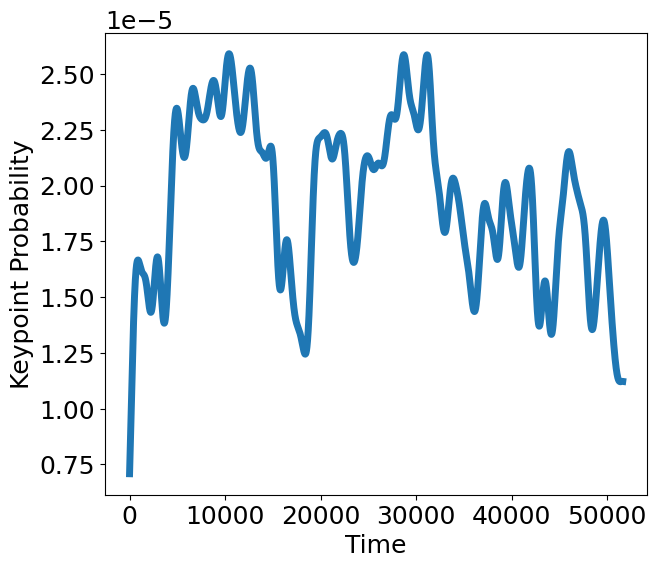

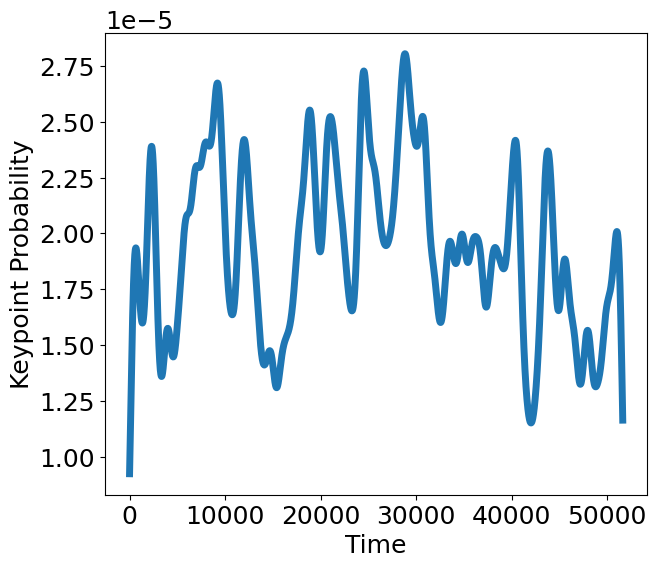

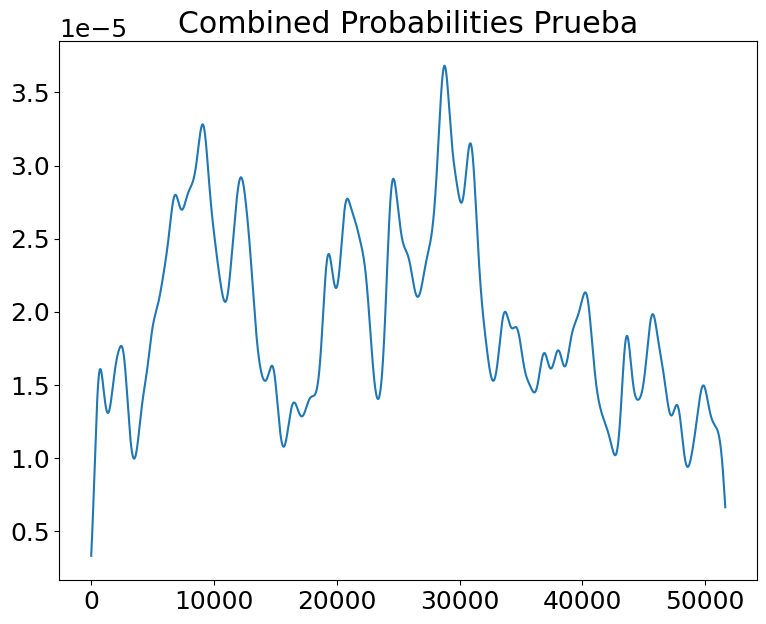

[  742  2441  6861  9075 12198 14718 16520 19340 20860 24607 28773 30874
 33707 34556 36901 38029 40235 43627 45725 47685 49846]


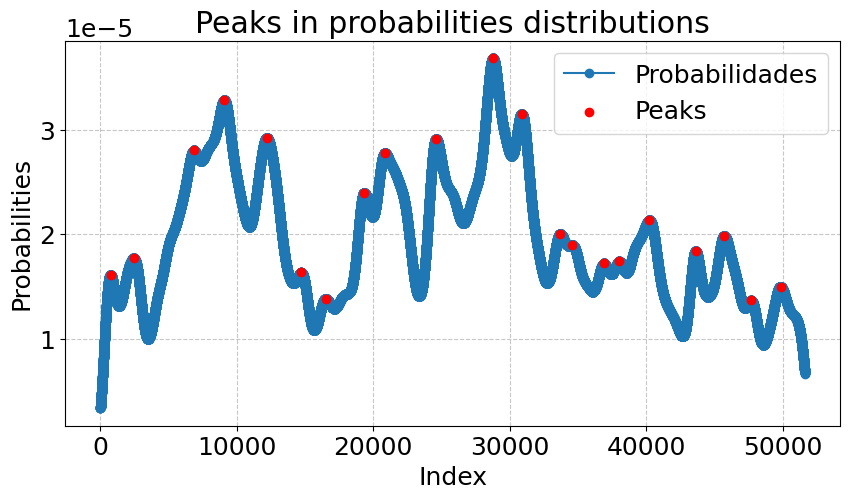

Sorted Keypoints [    0   742  2441  6861  9075 12198 14718 16520 19340 20860 24607 28773
 30874 33707 34556 36901 38029 40235 43627 45725 47685 49846 51634]
Valor de final keys [0]
Valor de final keys [0, 742]
Valor de final keys [0, 742, 2441]
Valor de final keys [0, 742, 2441, 6861]
Valor de final keys [0, 742, 2441, 6861, 9075]
Valor de final keys [0, 742, 2441, 6861, 9075, 12198]
Valor de final keys [0, 742, 2441, 6861, 9075, 12198, 14718]
Valor de final keys [0, 742, 2441, 6861, 9075, 12198, 14718, 16520]
Valor de final keys [0, 742, 2441, 6861, 9075, 12198, 14718, 16520, 19340]
Valor de final keys [0, 742, 2441, 6861, 9075, 12198, 14718, 16520, 19340, 20860]
Valor de final keys [0, 742, 2441, 6861, 9075, 12198, 14718, 16520, 19340, 20860, 24607]
Valor de final keys [0, 742, 2441, 6861, 9075, 12198, 14718, 16520, 19340, 20860, 24607, 28773]
Valor de final keys [0, 742, 2441, 6861, 9075, 12198, 14718, 16520, 19340, 20860, 24607, 28773, 30874]
Valor de final keys [0, 742, 2441, 686

In [86]:
# Concatenar todos los segmentos en un solo array
# all_segments_flat = np.concatenate(all_segments).reshape(-1, 1)

segments = probabilistically_combine(
    all_segments, len(demo), window_size=window_size, n_samples=200, n_pass=0, plot=True
)
# segments = probabilistically_combine(
#     all_segments, len(demo), window_size=1, n_samples=50, n_pass=2, plot=True
# )

Final Segments


/tmp/ipykernel_2171093/3136832674.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


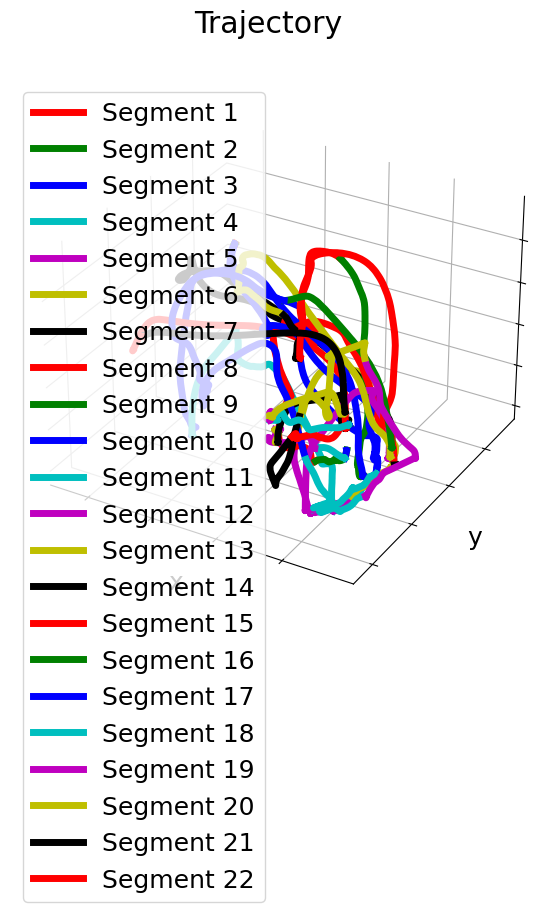

In [87]:
# segments = all_segments
print("Final Segments")
# Figura para visualizar los segmentos
plt.rcParams["figure.figsize"] = (9, 7)
fig = plt.figure()
fig.suptitle("Trajectory")
ax = plt.axes(projection="3d")
for j in range(len(all_demos)):
    demo = all_demos[j]

    # Aquí guardamos los segmentos de esta demo
    demo_segments = []

    for i in range(len(segments) - 1):
        segment = demo[segments[i] : segments[i + 1], :]
        demo_segments.append(segment)

        # * Draw each segments

        ax.plot3D(
            demo[segments[i] : segments[i + 1], 0],
            demo[segments[i] : segments[i + 1], 1],
            demo[segments[i] : segments[i + 1], 2],
            c=colors[i % len(colors)],
            label="Segment " + str(i + 1) if j == 0 else "",
            lw=5,
        )
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("z")
        # First remove fill
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        # Now set color to white (or whatever is "invisible")
        ax.xaxis.pane.set_edgecolor("w")
        ax.yaxis.pane.set_edgecolor("w")
        ax.zaxis.pane.set_edgecolor("w")
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_zticklabels([])
        ax.legend()
        plt.tight_layout()

    segment_data.append(demo_segments)

plt.show()

### Save segments

In [88]:
# Nombre de la carpeta donde guardaremos los archivos de los segmentos
folder_name = "SegmentsFolder"

# Crear la carpeta si no existe
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

# Suponiendo que all_demos es una lista de matrices, donde cada matriz tiene las coordenadas (x, y, z).
# Y que segments es una lista de índices que define cómo se dividen las demostraciones en segmentos.

# Variable para contar segmentos
segment_count = 0

for i in range(len(segments) - 1):
    segmentedData = []
    for j in range(len(all_demos)):
        # Extraer el segmento de la demo actual
        segment = all_demos[j][segments[i] : segments[i + 1]]
        segmentedData.append(segment)
        # Definir el nombre del archivo para este segmento
    segmentedData = np.concatenate(segmentedData, axis=0)
    filename = f"segmento{i + 1}.txt"  # Segmento se numera de acuerdo a la cuenta

    # Ruta del archivo
    file_path = os.path.join(folder_name, filename)

    # Abrir el archivo en modo escritura
    with open(file_path, "w") as f:
        # Escribir las coordenadas x, y, z en el archivo
        np.savetxt(
            f, segmentedData, comments="", fmt="%.6f"
        )  # Ajustar formato si es necesario

    print(f"Segmento guardado: {file_path}")

Segmento guardado: SegmentsFolder/segmento1.txt
Segmento guardado: SegmentsFolder/segmento2.txt
Segmento guardado: SegmentsFolder/segmento3.txt
Segmento guardado: SegmentsFolder/segmento4.txt
Segmento guardado: SegmentsFolder/segmento5.txt
Segmento guardado: SegmentsFolder/segmento6.txt
Segmento guardado: SegmentsFolder/segmento7.txt
Segmento guardado: SegmentsFolder/segmento8.txt
Segmento guardado: SegmentsFolder/segmento9.txt
Segmento guardado: SegmentsFolder/segmento10.txt
Segmento guardado: SegmentsFolder/segmento11.txt
Segmento guardado: SegmentsFolder/segmento12.txt
Segmento guardado: SegmentsFolder/segmento13.txt
Segmento guardado: SegmentsFolder/segmento14.txt
Segmento guardado: SegmentsFolder/segmento15.txt
Segmento guardado: SegmentsFolder/segmento16.txt
Segmento guardado: SegmentsFolder/segmento17.txt
Segmento guardado: SegmentsFolder/segmento18.txt
Segmento guardado: SegmentsFolder/segmento19.txt
Segmento guardado: SegmentsFolder/segmento20.txt
Segmento guardado: SegmentsFo

### Metrics

In [89]:
# if what_segments == "HigherLevel":
#     # Higher level change points
#     # cpd_segm_penalty = 125
#     cpd_segm_penalty = 9
#     true_chg_pts_iso = [segm["end"] for segm in gt_segm_dict[what_segments].values()]

# cpd_segm_penalty = 2
cpd_segm_penalty = 5
true_chg_pts_iso = []
for idx, skill in enumerate(gt_segm_dict["segments"].values()):
    if isinstance(skill, list):
        for segm in skill:
            if idx == 0:
                true_chg_pts_iso.append(segm["ini"])
            true_chg_pts_iso.append(segm["end"])
    elif isinstance(skill, dict):
        if idx == 0:
            true_chg_pts_iso.append(skill["ini"])
        true_chg_pts_iso.append(skill["end"])

    else:
        raise ValueError("Unexpected value in ground truth JSON file")

true_chg_pts_iso = sorted(list(set(sorted(true_chg_pts_iso))))
true_chg_pts_iso

[1769723215,
 1769723222,
 1769723226,
 1769723231,
 1769723234,
 1769723237,
 1769723239,
 1769723245,
 1769723248,
 1769723251,
 1769723253,
 1769723258,
 1769723262,
 1769723267,
 1769723270,
 1769723276,
 1769723280,
 1769723288,
 1769723296,
 1769723309,
 1769723313]

In [90]:
true_chg_pts = np.empty_like(true_chg_pts_iso) * np.nan
true_chg_pts

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan])

In [91]:
for idx in range(len(true_chg_pts)):
    true_chg_pts[idx] = traj[
        traj.timestamp
        >= pd.Timestamp(
            dt.datetime.fromtimestamp(
                true_chg_pts_iso[idx]
            ),  # - dt.timedelta(hours=1),
            tz="EST",
        )
    ].index[0]
# true_chg_pts = [int(item) for item in sorted(list(set(true_chg_pts)))]
true_chg_pts

array([ 2862.,  6351.,  8344., 10840., 12333., 13832., 14832., 17829.,
       19327., 20820., 21818., 24299., 26280., 28757., 30245., 33222.,
       35211., 39182., 43133., 49592., 51581.])

In [92]:
# true_chg_pts_resampled = [
#     round(item * resample_num / traj.index.stop) for item in true_chg_pts
# ]
# true_chg_pts_resampled = sorted(list(set(true_chg_pts_resampled)))
# true_chg_pts_resampled

In [93]:
true_chg_pts_resampled = list(true_chg_pts)

In [94]:
# if true_chg_pts_resampled[-1] != resample_num:
#     true_chg_pts_resampled.append(resample_num)
# true_chg_pts_resampled

In [95]:
len(traj)

53137

In [96]:
if true_chg_pts_resampled[-1] != len(traj):
    true_chg_pts_resampled.append(len(traj))
true_chg_pts_resampled

[2862.0,
 6351.0,
 8344.0,
 10840.0,
 12333.0,
 13832.0,
 14832.0,
 17829.0,
 19327.0,
 20820.0,
 21818.0,
 24299.0,
 26280.0,
 28757.0,
 30245.0,
 33222.0,
 35211.0,
 39182.0,
 43133.0,
 49592.0,
 51581.0,
 53137]

In [97]:
segments = list(segments)
if segments[-1] != len(traj):
    segments.append(len(traj))
segments

[0,
 742,
 2441,
 6861,
 9075,
 12198,
 14718,
 16520,
 19340,
 20860,
 24607,
 28773,
 30874,
 33707,
 34556,
 36901,
 38029,
 40235,
 43627,
 45725,
 47685,
 49846,
 51634,
 53137]

In [98]:
true_chg_pts_resampled, segments

([2862.0,
  6351.0,
  8344.0,
  10840.0,
  12333.0,
  13832.0,
  14832.0,
  17829.0,
  19327.0,
  20820.0,
  21818.0,
  24299.0,
  26280.0,
  28757.0,
  30245.0,
  33222.0,
  35211.0,
  39182.0,
  43133.0,
  49592.0,
  51581.0,
  53137],
 [0,
  742,
  2441,
  6861,
  9075,
  12198,
  14718,
  16520,
  19340,
  20860,
  24607,
  28773,
  30874,
  33707,
  34556,
  36901,
  38029,
  40235,
  43627,
  45725,
  47685,
  49846,
  51634,
  53137])

In [99]:
precision, recall = precision_recall(true_chg_pts_resampled, segments, margin=30)
precision, recall

(0.08695652173913043, 0.09523809523809523)

In [100]:
hausdorff(true_chg_pts_resampled, segments)

2862.0

In [101]:
# randindex([0, *true_chg_pts_resampled], segments[:-1])
randindex(true_chg_pts_resampled, list(segments))

0.9584942152139025

In [102]:
def rpt_display(
    signal,
    true_chg_pts,
    computed_chg_pts=None,
    computed_chg_pts_color="red",
    computed_chg_pts_linewidth=2.5,
    computed_chg_pts_linestyle="--",
    computed_chg_pts_alpha=0.5,
    **kwargs,
):
    """Display a signal and the change points provided in alternating colors.
    If another set of change point is provided, they are displayed with dashed
    vertical dashed lines. The following matplotlib subplots options is set by
    default, but can be changed when calling `display`):

    - figure size `figsize`, defaults to `(10, 2 * n_features)`.

    Args:
        signal (array): signal array, shape (n_samples,) or (n_samples, n_features).
        true_chg_pts (list): list of change point indexes.
        computed_chg_pts (list, optional): list of change point indexes.
        computed_chg_pts_color (str, optional): color of the lines indicating
            the computed_chg_pts. Defaults to "k".
        computed_chg_pts_linewidth (int, optional): linewidth of the lines
            indicating the computed_chg_pts. Defaults to 3.
        computed_chg_pts_linestyle (str, optional): linestyle of the lines
            indicating the computed_chg_pts. Defaults to "--".
        computed_chg_pts_alpha (float, optional): alpha of the lines indicating
            the computed_chg_pts. Defaults to "1.0".
        **kwargs : all additional keyword arguments are passed to the plt.subplots call.

    Returns:
        tuple: (figure, axarr) with a :class:`matplotlib.figure.Figure` object and an array of Axes objects.
    """
    # COLOR_CYCLE = ["#4286f4", "#f44174"]
    COLOR_CYCLE = mpl.colormaps.get("Pastel2").colors[2:4]

    try:
        import matplotlib.pyplot as plt
    except ImportError:
        raise MatplotlibMissingError(
            "This feature requires the optional dependency matpotlib, you can install it using `pip install matplotlib`."
        )

    if type(signal) != np.ndarray:
        # Try to get array from Pandas dataframe
        signal = signal.values

    if signal.ndim == 1:
        signal = signal.reshape(-1, 1)
    n_samples, n_features = signal.shape

    # let's set a sensible defaut size for the subplots
    matplotlib_options = {
        "figsize": (10, 2 * n_features),  # figure size
    }
    # add/update the options given by the user
    matplotlib_options.update(kwargs)

    # create plots
    fig, axarr = plt.subplots(n_features, sharex=True, **matplotlib_options)

    if n_features == 1:
        axarr = [axarr]

    labels_fontsize = 15
    for axe, sig in zip(axarr, signal.T):
        for item in (
            [axe.title, axe.xaxis.label, axe.yaxis.label]
            + axe.get_xticklabels()
            + axe.get_yticklabels()
        ):
            item.set_fontsize(labels_fontsize)
        if TRANSP_BACK_PLOT:
            axe.patch.set_alpha(0)
        axe.tick_params(color="gray")
        axe.spines[["right", "top"]].set_visible(False)
        for spine in axe.spines.values():
            spine.set_edgecolor("gray")
            spine.set_linewidth(1.5)

        color_cycle = cycle(COLOR_CYCLE)
        # plot s
        axe.plot(
            range(n_samples),
            sig,
            color="k",
            lw=computed_chg_pts_linewidth,
            alpha=computed_chg_pts_alpha,
        )

        # color each (true) regime
        bkps = [0] + sorted(true_chg_pts)
        # alpha = 0.2  # transparency of the colored background

        for (start, end), col in zip(rpt.utils.pairwise(bkps), color_cycle):
            axe.axvspan(
                max(0, start - 0.5),
                end - 0.5,
                facecolor=col,
                alpha=computed_chg_pts_alpha,
            )
        # vertical lines to mark the computed_chg_pts
        if computed_chg_pts is not None:
            for bkp in computed_chg_pts:
                if bkp != 0 and bkp < n_samples:
                    axe.axvline(
                        x=bkp - 0.5,
                        color=computed_chg_pts_color,
                        linewidth=computed_chg_pts_linewidth,
                        linestyle=computed_chg_pts_linestyle,
                        alpha=computed_chg_pts_alpha,
                        zorder=2.5,
                    )

    axe.set_xlabel("Time steps")
    if TRANSP_BACK_PLOT:
        fig.patch.set_alpha(0)
        # fig.patch.set_facecolor("white")
    fig.tight_layout()

    return fig, axarr

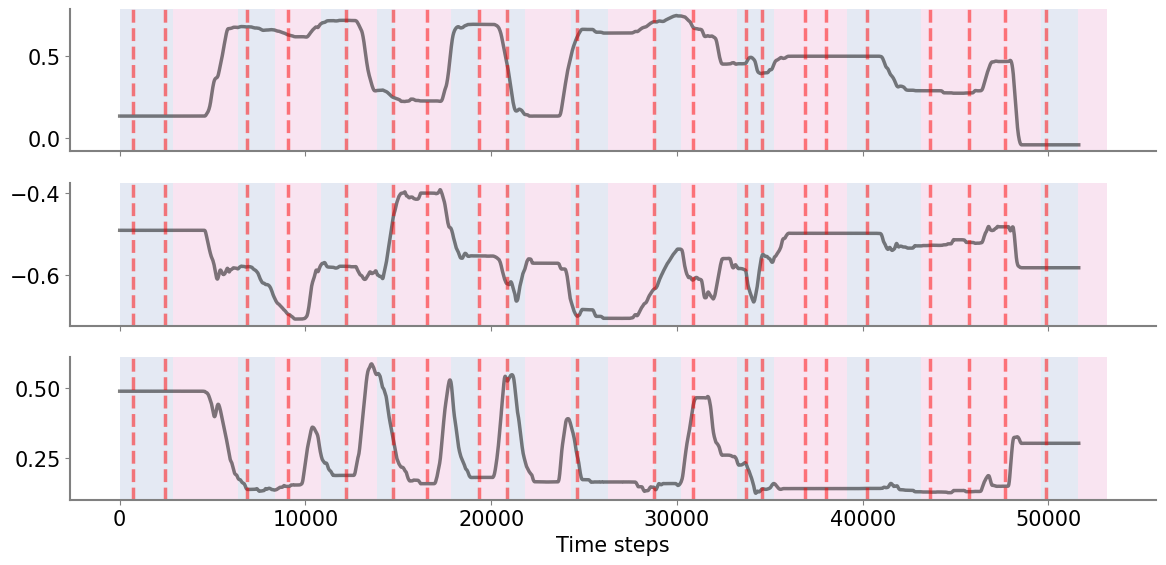

In [103]:
rpt_display(
    # signal=X_down_scaled,
    signal=demo,
    true_chg_pts=true_chg_pts_resampled,
    computed_chg_pts=segments,
    figsize=(12, demo.shape[1] * 2),
)
plt.show()